# REM Python Oefennotebook – Elektromagnetisme & Relativiteit

Dit notebook is bedoeld als **oefenpad** voor REM met Python.
Je werkt telkens in 3 stappen: **model** → **numerieke oplossing** → **visualisatie**.

## Inhoud
1. Lorentzkracht in homogeen magnetisch veld (baan van geladen deeltje)
2. Toevoegen van elektrisch veld (drift)
3. Relativistische correctie met $\gamma$
4. Wereldlijnen en Lorentztransformatie

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.style.use('seaborn-v0_8-whitegrid')
c = 299_792_458  # m/s

## 1) Lorentzkracht in homogeen B-veld

We lossen numeriek op:
$$
m\frac{d\mathbf{v}}{dt} = q(\mathbf{E} + \mathbf{v} \times \mathbf{B}),\quad \frac{d\mathbf{r}}{dt}=\mathbf{v}.
$$

Start met $\mathbf{E}=0$ en $\mathbf{B}=B\hat{z}$.
Dan verwacht je een cirkel/helicale beweging afhankelijk van $v_z$.

In [2]:
# Parameters
q = 1.602e-19        # C (protonlading)
m = 1.673e-27        # kg (protonmassa)
B0 = 1.0             # Tesla
E = np.array([0.0, 0.0, 0.0])
B = np.array([0.0, 0.0, B0])

# Beginvoorwaarden: r=(x,y,z), v=(vx,vy,vz)
y0 = np.array([0.0, 0.0, 0.0,
               2.0e6, 0.0, 0.5e6])

def rhs_nonrel(t, y, q, m, E, B):
    r = y[:3]
    v = y[3:]
    a = (q/m) * (E + np.cross(v, B))
    return np.hstack([v, a])

t_span = (0.0, 1.5e-6)
t_eval = np.linspace(*t_span, 3000)
sol = solve_ivp(rhs_nonrel, t_span, y0, t_eval=t_eval, args=(q, m, E, B), rtol=1e-8, atol=1e-10)

x, y, z = sol.y[0], sol.y[1], sol.y[2]
vx, vy, vz = sol.y[3], sol.y[4], sol.y[5]

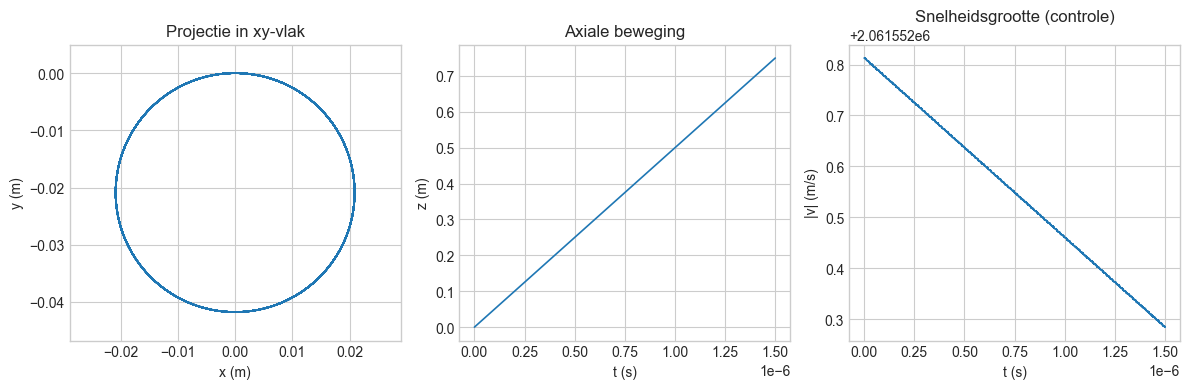

In [3]:
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(x, y, lw=1.2)
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_title('Projectie in xy-vlak')
ax1.axis('equal')

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(sol.t, z, lw=1.2)
ax2.set_xlabel('t (s)')
ax2.set_ylabel('z (m)')
ax2.set_title('Axiale beweging')

speed = np.sqrt(vx**2 + vy**2 + vz**2)
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(sol.t, speed, lw=1.2)
ax3.set_xlabel('t (s)')
ax3.set_ylabel('|v| (m/s)')
ax3.set_title('Snelheidsgrootte (controle)')

plt.tight_layout()
plt.show()

### Oefening 1
- Verander teken van $q$ en interpreteer de draairichting.
- Verander $B_0$ en controleer of de cyclotronfrequentie $\omega_c=qB/m$ schaalt zoals verwacht.
- Zet $v_z=0$ en controleer dat de baan zuiver cirkelvormig wordt.

## 2) E-veld toevoegen: $\mathbf{E} \perp \mathbf{B}$ drift

Voor homogeen $\mathbf{E}$ en $\mathbf{B}$ verwacht je gemiddeld een drift met
$$
\mathbf{v}_d = \frac{\mathbf{E} \times \mathbf{B}}{B^2}.
$$

Theoretische drift [m/s]: [     0. -15000.      0.]
Numerieke gemiddelde drift [m/s]: [ 14374.4896367  -13238.45864793      0.        ]


/Users/tristancools/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


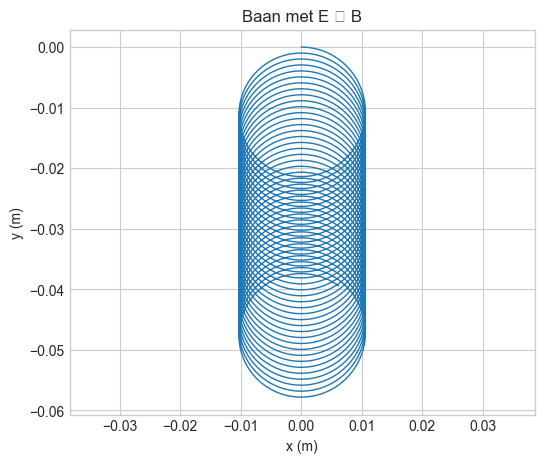

In [4]:
E2 = np.array([1.5e4, 0.0, 0.0])
B2 = np.array([0.0, 0.0, 1.0])
y0_2 = np.array([0.0, 0.0, 0.0,
                 1.0e6, 0.0, 0.0])

sol2 = solve_ivp(rhs_nonrel, (0, 2.5e-6), y0_2, t_eval=np.linspace(0, 2.5e-6, 4000),
                 args=(q, m, E2, B2), rtol=1e-8, atol=1e-10)

x2, y2 = sol2.y[0], sol2.y[1]
vx2, vy2 = sol2.y[3], sol2.y[4]

vd_theory = np.cross(E2, B2) / np.dot(B2, B2)
vx_mean = np.mean(vx2[int(0.6*len(vx2)):])
vy_mean = np.mean(vy2[int(0.6*len(vy2)):])

print('Theoretische drift [m/s]:', vd_theory)
print('Numerieke gemiddelde drift [m/s]:', np.array([vx_mean, vy_mean, 0.0]))

plt.figure(figsize=(6, 5))
plt.plot(x2, y2, lw=1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Baan met E ⟂ B')
plt.axis('equal')
plt.show()

### Oefening 2
- Scan over meerdere waarden van $E_x$ en vergelijk numerische drift met theorie.
- Bepaal de relatieve fout als functie van tijdstap/resolutie.
- Onderzoek wat er gebeurt als $\mathbf{E}$ ook een component langs $\mathbf{B}$ heeft.

## 3) Relativistische correctie

Niet-relativistisch geldt $\mathbf{a}=\frac{q}{m}(\mathbf{E}+\mathbf{v}\times\mathbf{B})$.
Relativistisch is het handiger om met impuls te werken:
\[
\frac{d\mathbf{p}}{dt}=q(\mathbf{E}+\mathbf{v}\times\mathbf{B}),\quad \mathbf{p}=\gamma m \mathbf{v},\quad \gamma=\frac{1}{\sqrt{1-v^2/c^2}}.
\]

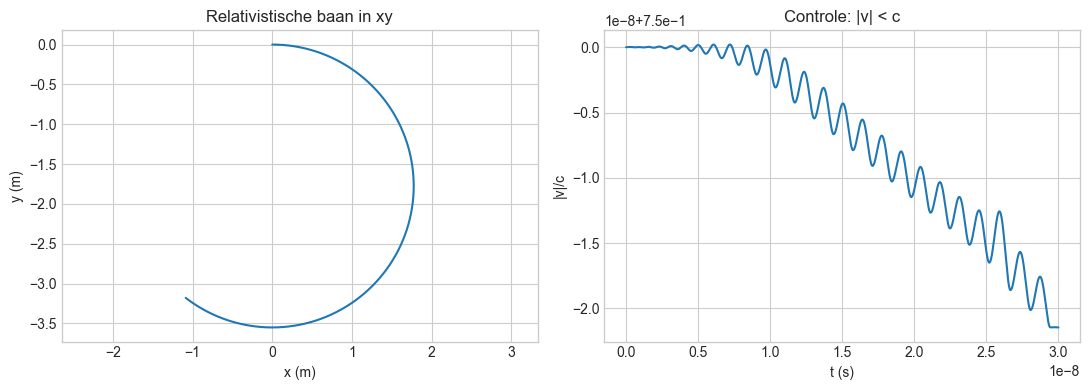

In [5]:
def rhs_relativistic(t, y, q, m, E, B):
    r = y[:3]
    p = y[3:]

    p2 = np.dot(p, p)
    gamma = np.sqrt(1.0 + p2/(m*m*c*c))
    v = p/(gamma*m)

    dpdt = q * (E + np.cross(v, B))
    drdt = v
    return np.hstack([drdt, dpdt])

# Hoge startsnelheid
v0 = np.array([0.75*c, 0.0, 0.0])
gamma0 = 1.0 / np.sqrt(1 - np.dot(v0, v0)/c**2)
p0 = gamma0 * m * v0
y0_rel = np.hstack([np.zeros(3), p0])

E3 = np.array([0.0, 0.0, 0.0])
B3 = np.array([0.0, 0.0, 2.0])

sol_rel = solve_ivp(rhs_relativistic, (0, 3e-8), y0_rel,
                    t_eval=np.linspace(0, 3e-8, 3000), args=(q, m, E3, B3),
                    rtol=1e-8, atol=1e-10)

xr, yr = sol_rel.y[0], sol_rel.y[1]
pr = sol_rel.y[3:].T
gamma_r = np.sqrt(1 + np.sum(pr*pr, axis=1)/(m*m*c*c))
vr = pr/(gamma_r[:, None]*m)
speed_r = np.linalg.norm(vr, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(xr, yr)
ax[0].set_xlabel('x (m)')
ax[0].set_ylabel('y (m)')
ax[0].set_title('Relativistische baan in xy')
ax[0].axis('equal')

ax[1].plot(sol_rel.t, speed_r/c)
ax[1].set_xlabel('t (s)')
ax[1].set_ylabel('|v|/c')
ax[1].set_title('Controle: |v| < c')

plt.tight_layout()
plt.show()

### Oefening 3
- Vergelijk niet-relativistische en relativistische baanstraal bij dezelfde beginvoorwaarden.
- Plot $\gamma(t)$ voor verschillende startsnelheden ($0.1c$, $0.5c$, $0.9c$).
- Zoek numeriek vanaf welke $v/c$ de klassieke benadering >1% fout geeft in baanstraal.

## 4) Lorentztransformatie en wereldlijnen

Voor een boost langs $x$:
$$
x' = \gamma(x-vt), \qquad t' = \gamma\left(t - \frac{vx}{c^2}\right).
$$

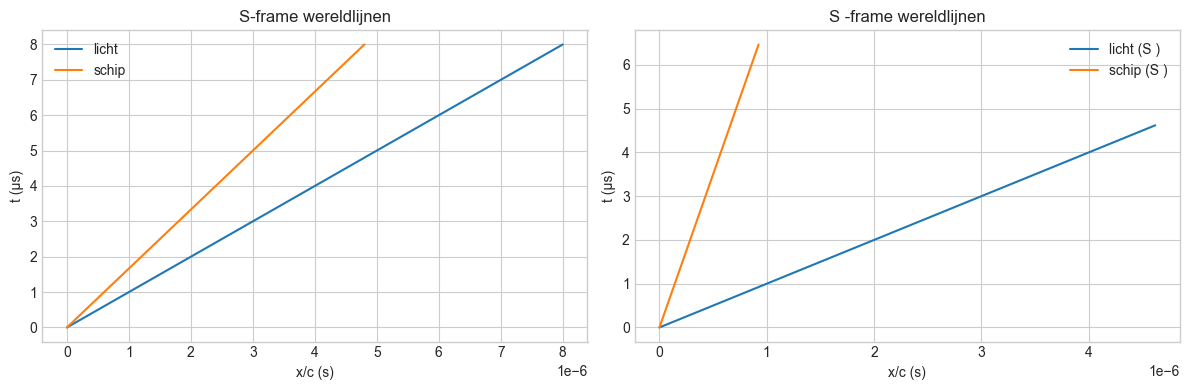

In [6]:
def lorentz_transform_x_t(x, t, v):
    beta = v / c
    gamma = 1.0 / np.sqrt(1 - beta**2)
    x_p = gamma * (x - v*t)
    t_p = gamma * (t - v*x/c**2)
    return x_p, t_p

t = np.linspace(0, 8e-6, 300)
x_light = c*t
x_ship = 0.6*c*t

v_frame = 0.5*c
x_light_p, t_light_p = lorentz_transform_x_t(x_light, t, v_frame)
x_ship_p, t_ship_p = lorentz_transform_x_t(x_ship, t, v_frame)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x_light/c, t*1e6, label='licht')
ax[0].plot(x_ship/c, t*1e6, label='schip')
ax[0].set_xlabel('x/c (s)')
ax[0].set_ylabel('t (μs)')
ax[0].set_title('S-frame wereldlijnen')
ax[0].legend()

ax[1].plot(x_light_p/c, t_light_p*1e6, label='licht (S )')
ax[1].plot(x_ship_p/c, t_ship_p*1e6, label='schip (S )')
ax[1].set_xlabel('x/c (s)')
ax[1].set_ylabel('t (μs)')
ax[1].set_title('S -frame wereldlijnen')
ax[1].legend()

plt.tight_layout()
plt.show()

### Oefening 4
- Voeg lijnen toe van gebeurtenissen met gelijke $t'$ en interpreteer relativiteit van simultaniteit.
- Simuleer een eenvoudige twin-scenario met stukgewijze snelheden.
- Bereken eigen tijd numeriek: $d\tau = dt/\gamma$.

## Extra examengerichte checklist

- Kan ik de fysische schaal schatten voor ik simuleer?
- Kloppen limieten? (bijv. $v\ll c$ geeft klassieke uitkomst)
- Heb ik conservatie/controleplots? (energie, snelheid, invarianten)
- Kan ik numerieke fout inschatten via `rtol/atol` en tijdresolutie?

Als je wil, maak ik hierna een **tweede notebook** met uitsluitend examenoefeningen (zonder uitgebreide hints).